###  Installation de l'environnement

In [41]:
%pip install -r ../../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Connexion à la DB DuckDB

In [27]:
import duckdb
import os
from pathlib import Path
from typing import List

import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


### Connexion à la DB / Import des Data


In [ ]:
# Store database at project root
DB_NAME = Path("../../amazing.duckdb") 
data_folder = Path("../../data") 
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")

con = duckdb.connect(str(DB_NAME))

In [29]:
df = con.execute("SELECT * FROM user_segments").fetchdf()

In [39]:
# Feature engineering
df["event_intensity"] = df["total_events"] / (df["days_since_last_event"] + 1)
df["view_to_purchase_ratio"] = df["total_views"] / (df["total_purchases"] + 1)
df["is_active"] = (df["days_since_last_event"] < 30).astype(int)

Meilleurs hyperparamètres trouvés :
{'clf__max_depth': 20, 'clf__max_features': 'sqrt', 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Score moyen : 0.9115208880503916
Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      7130
           1       1.00      1.00      1.00        44
           2       1.00      1.00      1.00      2313
           3       0.93      0.97      0.95      8443
           4       0.97      0.94      0.96      8884
           5       1.00      1.00      1.00       944

    accuracy                           0.97     27758
   macro avg       0.98      0.98      0.98     27758
weighted avg       0.97      0.97      0.97     27758



<Figure size 600x500 with 0 Axes>

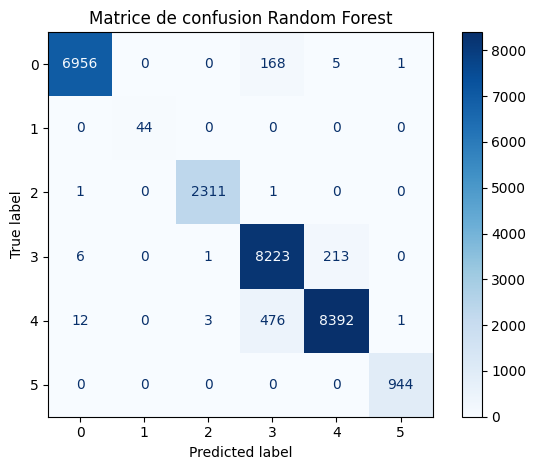

In [ ]:
# Séparation features / cibles
X = df.drop(columns=["segment", "user_id", "last_event_time"])
y = df["segment"]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=42))
])

# Paramètres à tester
param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [10, 20, 30],
    "clf__min_samples_split": [2, 5],
    "clf__max_features": ['sqrt', 'log2']
}

# Cross-validation stratifiée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch avec cross-validation
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X, y)

# Résultats
print("Meilleurs hyperparamètres trouvés :")
print(grid.best_params_)

print("Score moyen :", grid.best_score_)

# Prédictions finales (pour reporting)
y_pred = grid.predict(X)

# Rapport de classification
print("Rapport de classification :")
print(classification_report(y, y_pred))

# Matrice de confusion
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=grid.classes_, cmap="Blues")
plt.title("Matrice de confusion Random Forest")
plt.tight_layout()
plt.show()

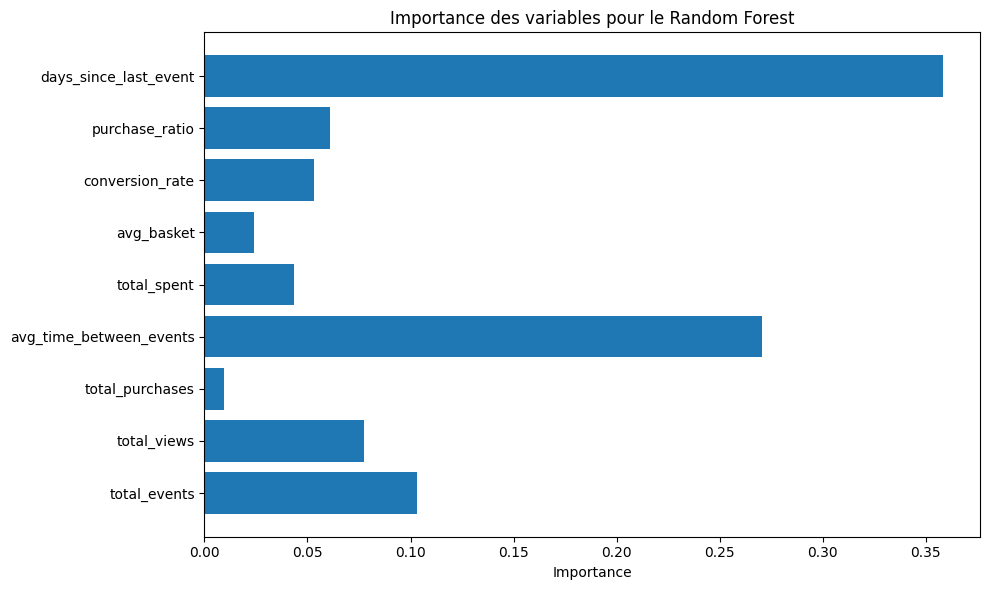

In [38]:
best_rf = grid.best_estimator_.named_steps["clf"]

# Affiche l'importance des features
importances = best_rf.feature_importances_
features = X.columns

# Affichage en barres
plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Importance des variables pour le Random Forest")
plt.tight_layout()
plt.show()

In [32]:
# Fermeture de la connexion DuckDB
con.close()